# Factor Correlation Analysis

This notebook analyzes the relationships among multiple quantitative factors:

- Momentum Factor
- Volatility Factor
- Size Factor

The goal is to identify whether factors provide unique information or are highly correlated.

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
# Download data

data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Flatten columns if needed
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Create factors

data["Momentum_20"] = data["Close"].pct_change(20)

data["Volatility_20"] = (
    data["Close"].pct_change().rolling(20).std()
)

data["Size_Factor"] = np.log(data["Volume"])

# Keep factor columns only
factor_data = data[
    ["Momentum_20", "Volatility_20", "Size_Factor"]
].dropna()

factor_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Momentum_20,Volatility_20,Size_Factor
Date,,,
2023-02-01,0.162789,0.012758,18.167897
2023-02-02,0.193574,0.014354,18.589064
2023-02-03,0.235802,0.013969,18.854781
2023-02-06,0.170575,0.013955,18.061979
2023-02-07,0.188244,0.014142,18.238230


In [15]:
# Correlation matrix

corr_matrix = factor_data.corr()

print(corr_matrix)

Price          Momentum_20  Volatility_20  Size_Factor
Price                                                 
Momentum_20       1.000000      -0.183948     0.026536
Volatility_20    -0.183948       1.000000     0.301265
Size_Factor       0.026536       0.301265     1.000000


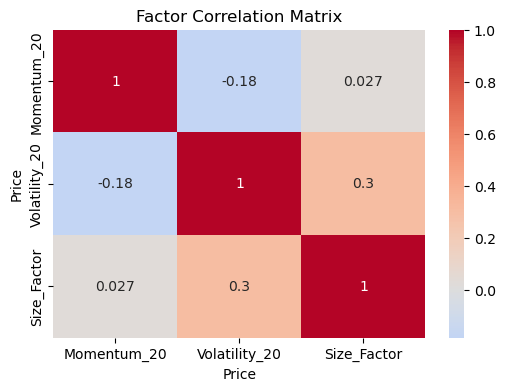

In [16]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Factor Correlation Matrix")
plt.show()

## Results Interpretation

The factor correlation matrix shows relatively low correlations among the three factors.

- Momentum and Volatility have a weak negative correlation (-0.18).
- Momentum and Size have almost no correlation (0.03).
- Volatility and Size have a weak positive correlation (0.30).

Since all correlations are relatively small, these factors provide different information and may be combined in a multi-factor strategy to improve diversification.

The factor correlation analysis indicates that the selected factors are not highly correlated. Low correlations suggest that Momentum, Volatility, and Size capture different market characteristics and can be used together in a multi-factor model.